In [17]:
#import statements
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
#filepath
filepath="C:\\Users\\hp\\Downloads\\titanic.csv"

In [6]:
#read csv
df=pd.read_csv(filepath)

In [8]:
#show headers
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
df.shape

(891, 12)

In [10]:
df.duplicated().value_counts()

False    891
Name: count, dtype: int64

In [11]:
print(df.isnull().sum())
missing=df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


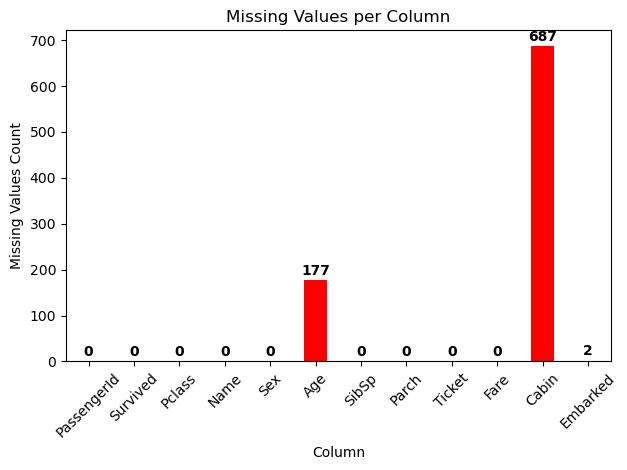

In [27]:
#Bar Chart
ax=missing.plot(kind="bar",color="red")
plt.title("Missing Values per Column")
plt.xlabel("Column")
plt.ylabel("Missing Values Count")
plt.xticks(rotation=45)
for index, value in enumerate(missing):
    plt.text(index, value + 5, str(value), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [38]:
df=df.drop(columns=["Cabin"],errors='ignore')

In [39]:
#Survival Counts
survival_counts = df['Survived'].value_counts()
print("Survival Counts:\n", survival_counts)

Survival Counts:
 Survived
0    549
1    342
Name: count, dtype: int64


C:\Users\hp\AppData\Local\Temp\ipykernel_5580\927445151.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='pastel')


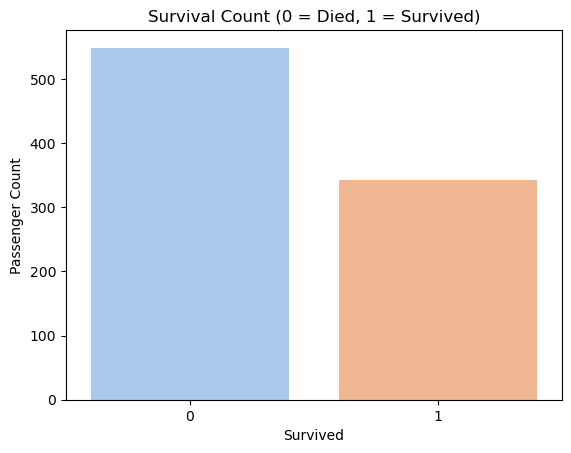

In [40]:
sns.countplot(x='Survived', data=df, palette='pastel')
plt.title('Survival Count (0 = Died, 1 = Survived)')
plt.xlabel('Survived')
plt.ylabel('Passenger Count')
plt.show()

In [41]:
#count of passangers by gender
gender_counts = df['Sex'].value_counts()
print("\nGender Counts:\n", gender_counts)


Gender Counts:
 Sex
male      577
female    314
Name: count, dtype: int64


In [42]:
#Count of survived groups by gender
survival_by_gender = df.groupby(['Sex', 'Survived']).size()
print("\nSurvival by Gender:\n", survival_by_gender)


Survival by Gender:
 Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
dtype: int64


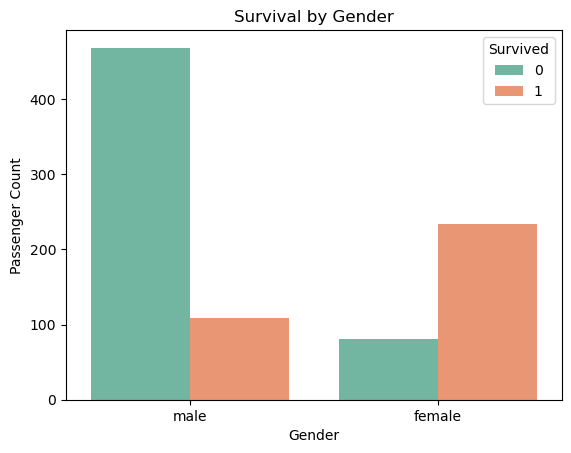

In [43]:
sns.countplot(x='Sex', hue='Survived', data=df, palette='Set2')
plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Passenger Count')
plt.legend(title='Survived')
plt.show()

In [44]:
#Passengers Count by class
pclass_counts = df['Pclass'].value_counts()
print("\nPassenger Class Counts:\n", pclass_counts)


Passenger Class Counts:
 Pclass
3    491
1    216
2    184
Name: count, dtype: int64


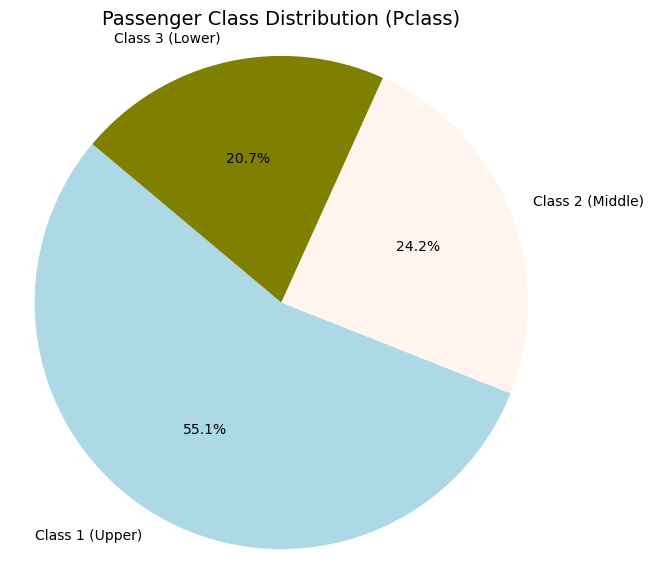

In [45]:
# Labels for the pie chart
labels = ['Class 1 (Upper)', 'Class 2 (Middle)', 'Class 3 (Lower)']

# Plotting the pie chart
plt.figure(figsize=(7, 7))
plt.pie(pclass_counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=['lightblue', 'seashell', 'olive'])
plt.title('Passenger Class Distribution (Pclass)', fontsize=14)
plt.axis('equal')  # Ensures it's a circle
plt.show()

In [46]:
sns.kdeplot(df['Age'], fill=True, color='skyblue')
plt.title('Age Distribution (KDE Plot)')
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()

KeyError: 'Age'

In [47]:
sns.kdeplot(df['Age'], fill=True, color='skyblue')
plt.title('Age Distribution (KDE Plot)')
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()

KeyError: 'Age'

In [48]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 40, 60, 100], labels=['Child', 'Teen', 'Adult', 'Middle Age', 'Senior'])
sns.countplot(x='AgeGroup', hue='Survived', data=df)
plt.title('Survival by Age Group')
plt.show()

KeyError: 'Age'